In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
np.random.seed(42)

# Cluster 1
X1 = np.random.randn(50, 2) + np.array([2, 2])

# Cluster 2
X2 = np.random.randn(50, 2) + np.array([8, 8])

# 合并成一个数据集
X = np.vstack([X1, X2])

print("X shape =", X.shape)
print(X[:5])

X shape = (100, 2)
[[2.49671415 1.8617357 ]
 [2.64768854 3.52302986]
 [1.76584663 1.76586304]
 [3.57921282 2.76743473]
 [1.53052561 2.54256004]]


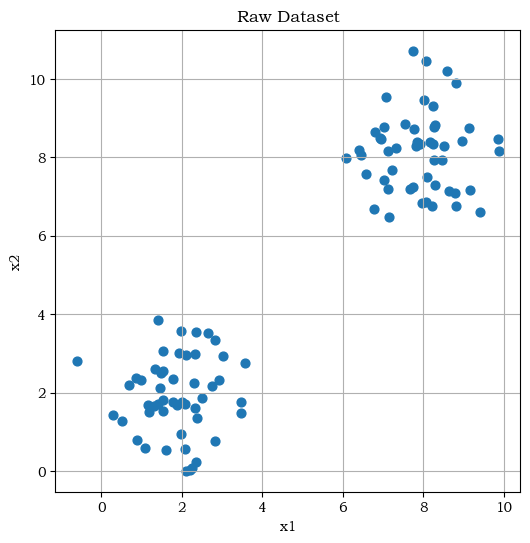

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Raw Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()


<div style="font-size: 0.85em; line-height: 1.1;">

### 5. Loss Function of K-Means

What K-Means aims to do:

* Minimize the distance between each sample point and its assigned cluster center.

Its loss function is:

$$J = \sum_{i=1}^{n} ||x_i - \mu_{c_i}||^2$$

Where:

* **$x_i$**: The $i$-th sample
* **$c_i$**: The cluster ID to which the $i$-th sample belongs
* **$\mu_{c_i}$**: The center of that cluster
* **$||x_i - \mu_{c_i}||^2$**: The squared distance from the sample to the center

</div>


In [ ]:
def compute_loss(X, labels, centroids):
    loss = 0.0
    for i in range(len(X)):
        center = centroids[labels[i]] # 根据标签获取该样本所属簇的中心点
        loss += np.sum((X[i] - center) ** 2)
    return loss

<div style="font-size: 0.85em; line-height: 1.1;">

### 8. Core Steps of K-Means

K-Means iteratively performs two steps:

**Step 1: Assignment**
Assign each point to the nearest cluster center.

**Step 2: Update**
Update the center of each cluster to the mean value of all points in that cluster.

Repeat until the centers essentially stop changing.

</div>

<div style="font-size: 0.85em; line-height: 1.1;">

### 11. If You Must Write It in "Gradient" Form

For a certain cluster $k$, the loss can be written as:

$$J_k = \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

Taking the derivative with respect to $\mu_k$:

$$\frac{\partial J_k}{\partial \mu_k} = 2 \sum_{x_i \in C_k} (\mu_k - x_i)$$

Setting the derivative to 0:

$$2 \sum_{x_i \in C_k} (\mu_k - x_i) = 0$$

Resulting in:

$$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$

Therefore:

* The "gradient object" of K-Means is not $w, b$
* But each centroid: $\mu_k$

</div>

In [ ]:
def initialize_centroids(X, K):
    
    # 从 0 到 n-1 的整数中随机抽取 K size 个，不重复
    # X 有 100 个样本，K=3, indices = [42, 17, 85]  # 随机选择的3个不同索引
    indices = np.random.choice(len(X), K, replace=False) 
    return X[indices].copy() # 使用整数数组索引，从 X 中取出对应索引位置的样本

In [35]:
def assign_clusters(X, centroids):
    labels = []
    for x in X:
        distances = np.linalg.norm(x - centroids, axis=1) # d₁ = √[(x₁-c₁₁)² + (x₂-c₁₂)²]
        label = np.argmin(distances) # 找出最近的中心对应的索引
        labels.append(label)
    return np.array(labels)

In [ ]:
def update_centroids(X, labels, K):
    new_centroids = []
    for k in range(K):
        cluster_points = X[labels == k] # 标记所有属于簇 k 的样本位置
        new_centroid = cluster_points.mean(axis=0) # 计算平均值，得到该簇的新中心点
        new_centroids.append(new_centroid)
    return np.array(new_centroids)

In [41]:
def kmeans_train_with_history(X, K=3, max_iters=10):
    centroids = initialize_centroids(X, K)

    centroid_history = [centroids.copy()]
    label_history = []
    loss_history = []

    for step in range(max_iters):
        # Step 1: assign clusters
        labels = assign_clusters(X, centroids)

        # Step 2: compute loss
        loss = compute_loss(X, labels, centroids)

        # Save current state
        label_history.append(labels.copy())
        loss_history.append(loss)

        # Step 3: update centroids
        new_centroids = update_centroids(X, labels, K)
        centroid_history.append(new_centroids.copy())

        # Step 4: convergence check
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {step}")
            centroids = new_centroids
            break

        centroids = new_centroids

    return centroids, labels, centroid_history, label_history, loss_history

In [42]:
K = 3
final_centroids, final_labels, centroid_history, label_history, loss_history = kmeans_train_with_history(
    X, K=K, max_iters=10
)

print("Final centroids:")
print(final_centroids)

print("Loss history:")
print(loss_history)

Converged at iteration 5
Final centroids:
[[7.90454712 8.14006205]
 [2.00361029 2.48816637]
 [1.61670496 0.93210033]]
Loss history:
[180.74161279401488, 142.04492005543003, 141.37426531251933, 141.2077856518689, 140.6539121951079, 140.58484419686403]


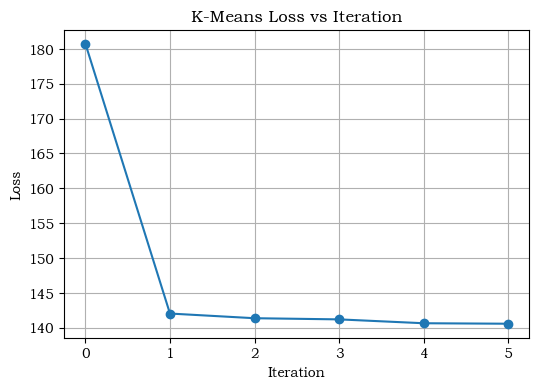

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker='o')
plt.title("K-Means Loss vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

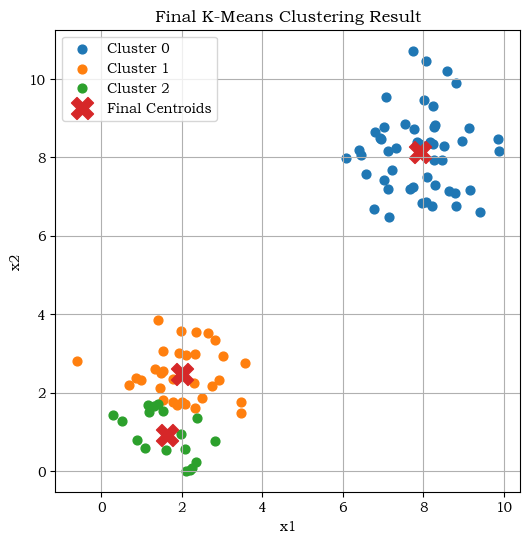

In [44]:
plt.figure(figsize=(6, 6))

for k in range(K):
    cluster_points = X[final_labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=40, label=f"Cluster {k}")

plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            s=250, marker='X', label='Final Centroids')

plt.title("Final K-Means Clustering Result")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7, 7))

# 为了坐标范围固定，避免动画时图像跳动
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

def update(frame):
    ax.clear()

    labels = label_history[min(frame, len(label_history)-1)]
    centroids = centroid_history[min(frame, len(centroid_history)-1)]

    # 画每个 cluster 的点
    for k in range(K):
        cluster_points = X[labels == k]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   s=40, label=f"Cluster {k}")

    # 画当前中心
    ax.scatter(centroids[:, 0], centroids[:, 1],
               s=300, marker='X', linewidths=2, label='Centroids')

    # 如果不是第0帧，还画出中心移动轨迹
    if frame > 0:
        for k in range(K):
            path = np.array([c[k] for c in centroid_history[:frame+1]])
            ax.plot(path[:, 0], path[:, 1], '--', alpha=0.7)

    ax.set_title(f"K-Means Animation: Iteration {frame}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend(loc="upper right")

ani = FuncAnimation(fig, update, frames=len(centroid_history), interval=1000, repeat=False)

plt.close(fig)
HTML(ani.to_jshtml())